# SAP-RPT-1-OSS — Pilot Evaluation on `credit-g` (Kaggle)

This notebook is **Phase 1** of the SAP-RPT-1 standalone evaluation plan: a single-dataset pilot
that validates the environment, the official model configuration, and the full metrics/charting
pipeline before scaling to all 15 datasets.

**What this notebook does NOT do:** no encoding, no scaling, no imputation, no hyperparameter
tuning, no custom wrapper logic around classification. The model is used exactly as shown in the
[official README](https://github.com/SAP-samples/sap-rpt-1-oss/blob/main/README.md):

```python
from sap_rpt_oss import SAP_RPT_OSS_Classifier
clf = SAP_RPT_OSS_Classifier(max_context_size=8192, bagging=8)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)
```

**Dataset:** `credit-g` (OpenML ID 31) — German credit risk data, 1,000 rows, 20 features, meaningful
column names. This is the same dataset used as the smoke test in `SAP_RPT1_EVAL_PLAN.md`.

**Target classification column:** `class` — whether the applicant is a **good** or **bad** credit
risk. We treat `bad` as the positive class (class = 1) since predicting credit risk is the point of
interest.

**Outline:**
1. Environment setup (GPU check, install, Hugging Face auth)
2. Load and verify the dataset
3. Dataset statistics
4. Exploratory charts (with interpretation)
5. Data preparation (minimal — split only)
6. What is actually "trained" here?
7. Run the model (frozen, recommended config)
8. Compute metrics
9. Result charts (with interpretation)
10. Save the run record
11. Pilot go/no-go summary


## 1. Environment setup

**Kaggle notebook settings required before running this cell:**
- Accelerator: **GPU** (P100 or T4 x2)
- Internet: **On**
- Add-ons → Secrets: add a secret named `HF_TOKEN` with a Hugging Face **read** token
  (the model checkpoint is gated behind HF login — see the README's Requirements section).

The install pulls the package straight from the official GitHub repo, exactly as documented
(`pip install git+https://github.com/SAP-samples/sap-rpt-1-oss`). No local modifications.

In [1]:
!pip install -q git+https://github.com/SAP-samples/sap-rpt-1-oss
!pip install -q scikit-learn pandas numpy matplotlib seaborn
print("Install complete.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 4.0 MB/s eta 0:00:00a 0:00:01
Install complete.


In [2]:
import torch

assert torch.cuda.is_available(), "No GPU detected — enable GPU in Notebook Settings before continuing."
gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {gpu_name}")
print(f"GPU memory: {gpu_mem_gb:.1f} GB")
print("Recommended by the README: >= 80 GB for max_context_size=8192, bagging=8.")
print("We will validate empirically in Section 7 whether this pilot dataset fits on this GPU.")

GPU: Tesla T4
GPU memory: 15.6 GB
Recommended by the README: >= 80 GB for max_context_size=8192, bagging=8.
We will validate empirically in Section 7 whether this pilot dataset fits on this GPU.


In [3]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(hf_token)
print("Hugging Face login OK.")

Hugging Face login OK.


In [4]:
# Instantiate the classifier once here so the checkpoint downloads now,
# isolating "environment/download broken" failures from "dataset broken" failures later.
from sap_rpt_oss import SAP_RPT_OSS_Classifier
import time

t0 = time.time()
_warmup_clf = SAP_RPT_OSS_Classifier(max_context_size=8192, bagging=8)
print(f"Checkpoint loaded in {time.time() - t0:.1f}s")
print(f"Peak GPU memory after load: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")
del _warmup_clf
torch.cuda.empty_cache()

2025-11-04_sap-rpt-one-oss.pt:   0%|          | 0.00/64.6M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Checkpoint loaded in 7.0s
Peak GPU memory after load: 0.40 GB


## 2. Load and verify the dataset

We load `credit-g` directly from OpenML by its ID (31) using `fetch_openml`, which returns the
data as a pandas DataFrame **with the original column names** — exactly what SAP-RPT-1 needs,
since the README states the model embeds column names and cell values itself.

We print several checks here on purpose: it's easy to load the *wrong* OpenML dataset by ID, so we
confirm the name, shape, and target column before doing anything else.

In [5]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml(data_id=31, as_frame=True)

print("OpenML dataset name  :", bunch.details.get("name"))
print("OpenML dataset id    :", bunch.details.get("id"))
print("Shape (rows, features):", bunch.data.shape)
print("Target column         :", bunch.target.name)
print()
print("Feature columns:")
print(list(bunch.data.columns))

OpenML dataset name  : credit-g
OpenML dataset id    : 31
Shape (rows, features): (1000, 20)
Target column         : class

Feature columns:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']


In [6]:
X_raw = bunch.data.copy()
y_raw = bunch.target.copy()

print("dtypes:")
print(X_raw.dtypes)
print()
print("Target value counts:")
print(y_raw.value_counts())
print()
print("Missing values per column (top 10):")
print(X_raw.isnull().sum().sort_values(ascending=False).head(10))

dtypes:
checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
dtype: object

Target value counts:
class
good    700
bad     300
Name: count, dtype: int64

Missing values per column (top 10):
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status         

**The target classification column is `class`.** It has two values, `good` and `bad`, describing
whether the loan applicant is a good or bad credit risk. The model predicts this label from the
20 feature columns (age, credit amount, duration, purpose, employment history, etc.) — a mix of
numeric and categorical fields, all with meaningful, human-readable names.

There are no missing values in `credit-g`, so the "any missing values are handled correctly" claim
in the README isn't exercised by this dataset — worth remembering when we later hit `titanic` or
`sick`, which do have missing data.

## 3. Dataset statistics

One summary block per the evaluation plan's "Dataset Metadata" fields: row/feature counts, the
categorical/numeric split (the plan flags SAP-RPT-1 as sensitive to `n_cat_features`), class
balance, and the column-name-type label (meaningful vs. generic) used later to test the plan's
central hypothesis.

In [7]:
n_rows, n_features = X_raw.shape
cat_cols = X_raw.select_dtypes(include=["category", "object"]).columns.tolist()
num_cols = X_raw.select_dtypes(exclude=["category", "object"]).columns.tolist()
class_balance = (y_raw == "bad").mean()  # fraction of positive (bad credit) class

stats = {
    "dataset_name": "credit-g",
    "openml_id": 31,
    "n_rows": n_rows,
    "n_features": n_features,
    "n_cat_features": len(cat_cols),
    "n_num_features": len(num_cols),
    "class_balance_positive_bad": round(class_balance, 4),
    "col_names_type": "meaningful",
}
for k, v in stats.items():
    print(f"{k:30s}: {v}")

dataset_name                  : credit-g
openml_id                     : 31
n_rows                        : 1000
n_features                    : 20
n_cat_features                : 13
n_num_features                : 7
class_balance_positive_bad    : 0.3
col_names_type                : meaningful


## 4. Exploratory charts

Each chart below comes with a short interpretation of *why it matters for this evaluation*, not
just what it shows.

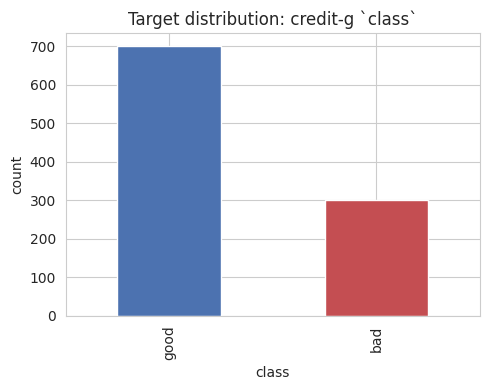

Majority-class baseline accuracy: 0.700


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(5, 4))
y_raw.value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Target distribution: credit-g `class`")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

majority_baseline = y_raw.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {majority_baseline:.3f}")

**Interpretation:** `credit-g` is imbalanced roughly 70/30 (good/bad). This matters two ways:
(1) a model that always predicts "good" would already score ~70% accuracy, so accuracy alone would
be misleading — F1/recall on the "bad" class and ROC-AUC are the honest metrics here; (2) this
majority-baseline number (printed above) is the number our model's accuracy needs to beat to prove
it's learning anything about *bad* credit risk specifically, not just guessing the common label.

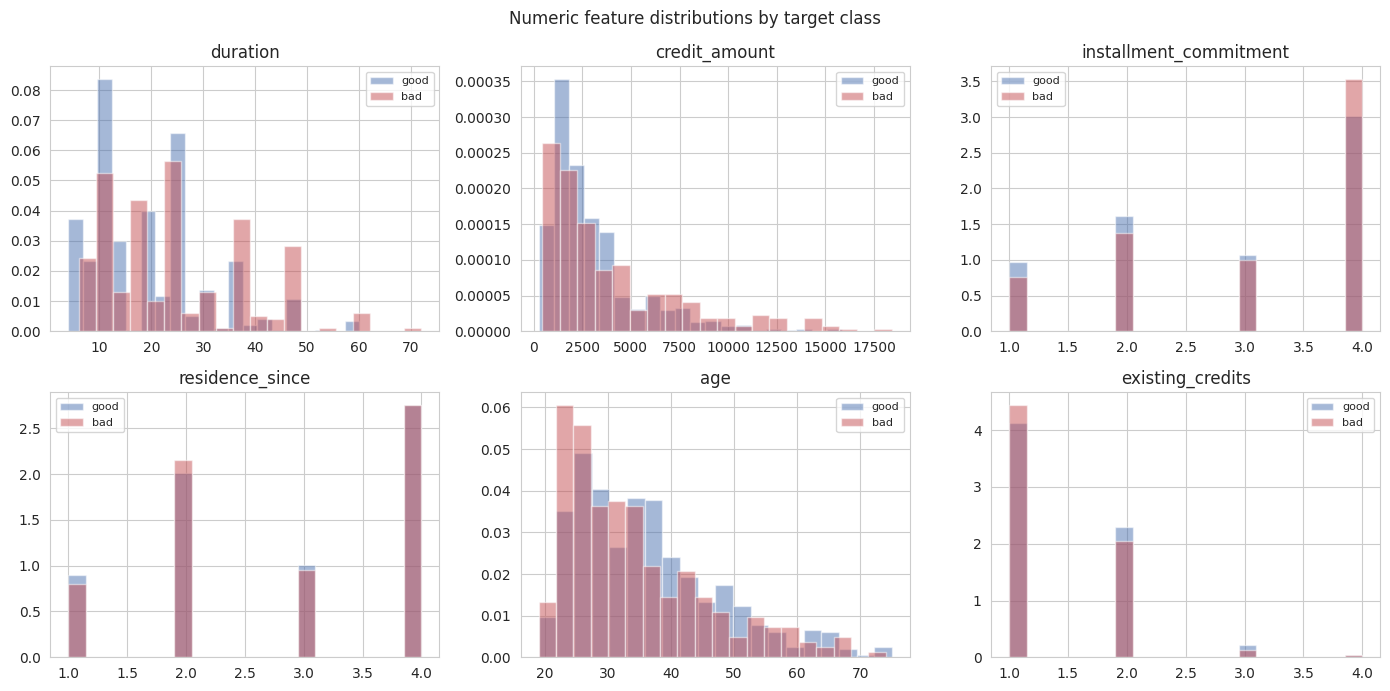

In [9]:
numeric_features = X_raw.select_dtypes(exclude=["category", "object"]).columns.tolist()
n_show = min(6, len(numeric_features))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_features[:n_show]):
    for cls, color in zip(["good", "bad"], ["#4C72B0", "#C44E52"]):
        subset = X_raw.loc[y_raw == cls, col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=cls, color=color, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle("Numeric feature distributions by target class")
plt.tight_layout()
plt.show()

**Interpretation:** where the blue (good) and red (bad) histograms clearly separate, that
feature carries signal a model could exploit. Where they sit on top of each other, that feature is
close to uninformative on its own. This gives us a visual expectation for AUC *before* running the
model — if nothing separates here, a modest AUC later is a property of the data, not a model
failure.

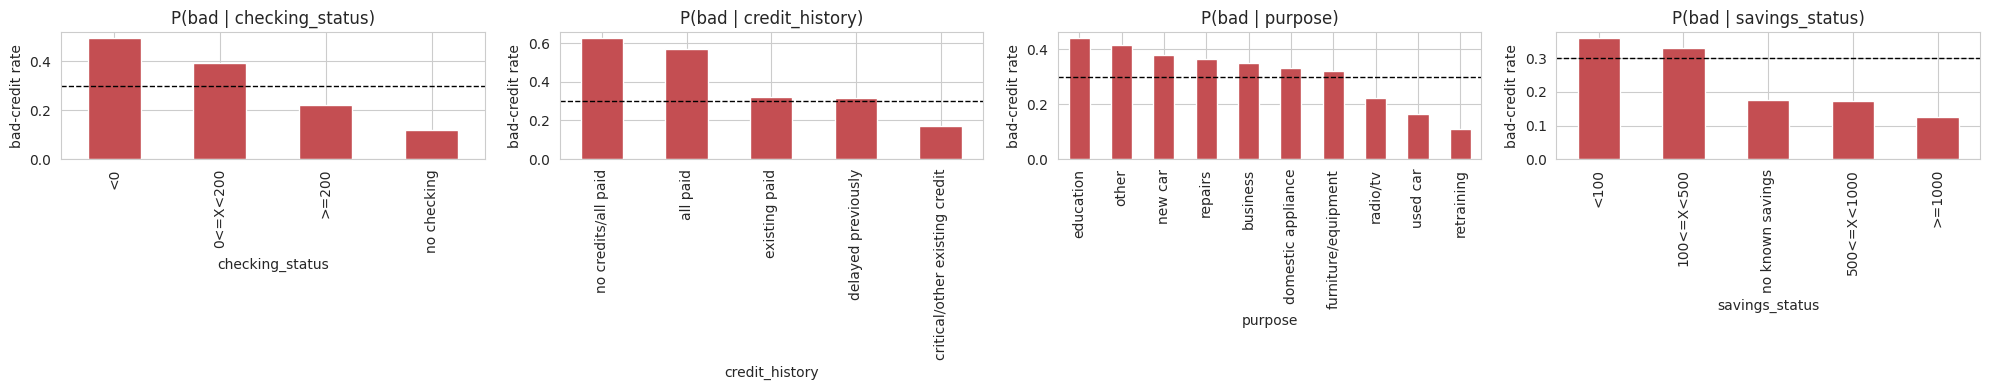

In [10]:
categorical_features = X_raw.select_dtypes(include=["category", "object"]).columns.tolist()
n_show = min(4, len(categorical_features))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4))
if n_show == 1:
    axes = [axes]

for i, col in enumerate(categorical_features[:n_show]):
    rate = y_raw.eq("bad").groupby(X_raw[col], observed=True).mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=axes[i], color="#C44E52")
    axes[i].axhline(class_balance, color="black", linestyle="--", linewidth=1)
    axes[i].set_title(f"P(bad | {col})")
    axes[i].set_ylabel("bad-credit rate")

plt.tight_layout()
plt.show()

**Interpretation:** each bar shows the bad-credit rate within a category of that column; the
dashed line is the overall base rate. Categories that swing well above or below the dashed line
(e.g., certain `checking_status` or `purpose` values) are informative splits a tree- or attention-
based model can exploit — and since SAP-RPT-1 reads the *category names themselves* (not just
integer codes), category labels like "no checking account" vs. "critical/other credit" carry real
semantic weight for this model specifically.

## 5. Data preparation (deliberately minimal)

Per the README, SAP-RPT-1 requires **no preprocessing** — it embeds raw column names and cell
values with an LLM internally. So we do the minimum needed to get a fair train/test split and a
numeric target for scoring, and nothing else:

- **No** one-hot encoding of categoricals
- **No** label-encoding of feature columns
- **No** scaling/normalization of numeric columns
- **No** imputation (credit-g has no missing values anyway)

We do map the target string labels to {0, 1} purely so that scikit-learn's metric functions have
something numeric to compare against — the *features* passed to the model stay completely raw.

The 80/20 split with `random_state=42` matches `DataLoader(test_size=0.2, random_state=42)` in
`SAP_RPT1_EVAL_PLAN.md`.

In [11]:
from sklearn.model_selection import train_test_split

y_binary = (y_raw == "bad").astype(int)  # positive class = bad credit risk

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train class balance (positive/bad):", y_train.mean().round(4))
print("Test class balance (positive/bad):", y_test.mean().round(4))
print()
print("Feature dtypes passed to the model (unchanged from raw load):")
print(X_train.dtypes)

X_train: (800, 20)  X_test: (200, 20)
Train class balance (positive/bad): 0.3
Test class balance (positive/bad): 0.3

Feature dtypes passed to the model (unchanged from raw load):
checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
dtype: object


## 6. What is actually being "trained" here?

SAP-RPT-1 is a **tabular in-context learner** (formerly named ConTextTab), not a model that is
gradient-trained on your data. The model's weights are frozen — pretrained by SAP on large-scale
real-world tabular data. Calling `.fit(X_train, y_train)` does not run backpropagation on this
dataset; it simply **stores the training rows as "context."** At prediction time, each test row is
answered by having the transformer attend over those stored context rows — conceptually similar to
giving a large language model worked examples inside its prompt, rather than fine-tuning it.

`bagging=8` means the model runs **8 forward passes** with different context subsamples/orderings
and averages the results — this is an inference-time ensembling trick, not 8 training epochs.

For this pilot: 800 training rows will be stored as context (well under the `max_context_size=8192`
cap, so **all** of them are used, no subsampling); 200 test rows will be predicted; 8 bagged forward
passes will be averaged per prediction.

## 7. Run the model (frozen, recommended configuration)

Exactly the README's classification usage — `max_context_size=8192, bagging=8` — with no
alteration. We time `fit` and `predict_proba` separately per the evaluation plan's timing fields,
and track peak GPU memory as the pilot's key go/no-go signal for running the recommended config on
Kaggle hardware.

In [12]:
torch.cuda.reset_peak_memory_stats()

clf = SAP_RPT_OSS_Classifier(max_context_size=8192, bagging=8)

t0 = time.time()
clf.fit(X_train, y_train)
fit_time_sec = time.time() - t0

t0 = time.time()
proba = clf.predict_proba(X_test)
predict_time_sec = time.time() - t0

preds = clf.predict(X_test)
total_wall_time_sec = fit_time_sec + predict_time_sec
peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

print(f"classes_          : {clf.classes_}")
print(f"fit_time_sec      : {fit_time_sec:.2f}")
print(f"predict_time_sec  : {predict_time_sec:.2f}")
print(f"total_wall_time_sec: {total_wall_time_sec:.2f}")
print(f"peak GPU memory   : {peak_mem_gb:.2f} GB")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


classes_          : [0 1]
fit_time_sec      : 0.00
predict_time_sec  : 1.47
total_wall_time_sec: 1.47
peak GPU memory   : 0.89 GB


**Go/no-go check:** if the cell above completed without a CUDA out-of-memory error, the
recommended config (`max_context_size=8192, bagging=8`) fits on this Kaggle GPU for a dataset this
size. If it OOM'd, the documented fallback is the README's own lightweight setting
(`max_context_size=2048, bagging=1`), applied uniformly across all 15 datasets and recorded as a
platform constraint — not per-dataset tuning.

In [19]:
# A readable sample of individual predictions, with original feature values alongside
n_preview_cols = 6  # first few feature columns, to keep the table readable
preview_features = X_test.columns[:n_preview_cols]

preds_table = X_test[preview_features].copy()
preds_table["true_label"] = y_test.map({0: "good", 1: "bad"}).values
preds_table["predicted_label"] = pd.Series(preds).map({0: "good", 1: "bad"}).values
preds_table["predicted_P(bad)"] = proba_positive.round(3)
preds_table["correct"] = (y_test.values == preds)

# Show 10 random rows, plus force-include a few disagreements so mistakes are visible
correct_sample = preds_table[preds_table["correct"]].sample(min(6, preds_table["correct"].sum()), random_state=0)
wrong_sample = preds_table[~preds_table["correct"]].sample(min(4, (~preds_table["correct"]).sum()), random_state=0) \
    if (~preds_table["correct"]).any() else preds_table.iloc[0:0]

pd.concat([correct_sample, wrong_sample]).sort_index()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,true_label,predicted_label,predicted_P(bad),correct
6,no checking,24,existing paid,furniture/equipment,2835,500<=X<1000,good,good,0.059,True
107,0<=X<200,12,existing paid,new car,6078,<100,good,good,0.235,True
112,0<=X<200,18,existing paid,new car,6260,<100,good,good,0.405,True
142,<0,27,existing paid,radio/tv,3416,<100,good,good,0.480,True
412,no checking,12,critical/other existing credit,business,2292,<100,bad,good,0.155,False
473,no checking,6,existing paid,retraining,1238,no known savings,good,good,0.093,True
594,<0,24,all paid,other,1358,no known savings,bad,good,0.387,False
658,0<=X<200,30,no credits/all paid,business,4221,<100,good,bad,0.569,False
772,no checking,21,critical/other existing credit,used car,3275,<100,good,good,0.060,True
996,<0,30,existing paid,used car,3857,<100,good,bad,0.530,False


## 8. Metrics

The full metric set from `SAP_RPT1_EVAL_PLAN.md`: ROC-AUC as the primary ranking metric, plus
accuracy, F1, log-loss, precision, and recall as secondary metrics, plus the three timing fields
already captured above.

**Diagnostics note:** the eval plan's internal wrapper had to *guess* which `predict_proba` column
represented P(class=1) (`pos_col`, `calibration_margin`) because that wrapper is a research
harness. The official `SAP_RPT_OSS_Classifier` follows the standard scikit-learn convention and
exposes `clf.classes_` directly, so no guessing is needed — we just look up the column index for
the positive class we defined (`1` = bad credit) in `clf.classes_`.

In [13]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    log_loss, precision_score, recall_score
)
import numpy as np

pos_col = int(np.where(clf.classes_ == 1)[0][0])
proba_positive = proba[:, pos_col]

metrics = {
    "roc_auc": roc_auc_score(y_test, proba_positive),
    "accuracy": accuracy_score(y_test, preds),
    "f1": f1_score(y_test, preds),
    "log_loss": log_loss(y_test, proba),
    "precision": precision_score(y_test, preds),
    "recall": recall_score(y_test, preds),
}

for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

print()
print("Sanity check — AUC should be well above 0.5 (random):", metrics["roc_auc"] > 0.5)
print("Expected range from SAP_RPT1_EVAL_PLAN.md for credit-g: 0.52-0.62")
in_range = 0.52 <= metrics["roc_auc"] <= 0.62
print("Result falls within expected range:", in_range,
      "(outside-range is not necessarily wrong, but merits a closer look)")

roc_auc   : 0.8043
accuracy  : 0.7950
f1        : 0.6019
log_loss  : 0.4770
precision : 0.7209
recall    : 0.5167

Sanity check — AUC should be well above 0.5 (random): True
Expected range from SAP_RPT1_EVAL_PLAN.md for credit-g: 0.52-0.62
Result falls within expected range: False (outside-range is not necessarily wrong, but merits a closer look)


## 9. Result charts

Each chart is followed by a short interpretation tying it back to what it tells us about model
quality on this dataset.

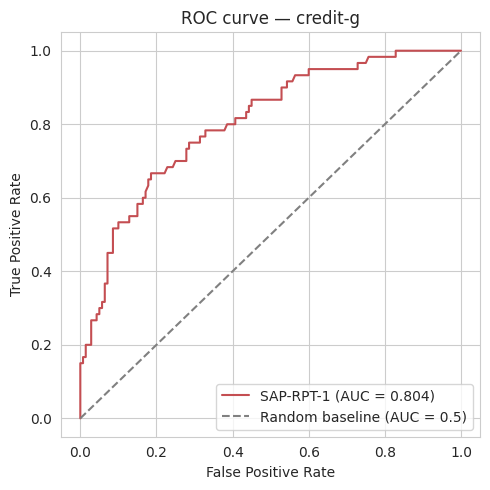

In [22]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, proba_positive)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#C44E52", label=f"SAP-RPT-1 (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random baseline (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — credit-g")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Table of points used to draw the ROC curve
roc_table = pd.DataFrame({
    "threshold": thresholds,
    "false_positive_rate": fpr,
    "true_positive_rate": tpr,
})

# thresholds[0] is often set to inf by sklearn as a starting point — drop it for readability
roc_table = roc_table[roc_table["threshold"] != np.inf].reset_index(drop=True)

# Show an evenly spaced sample of ~15 rows so it's readable instead of every single threshold
sample_idx = np.linspace(0, len(roc_table) - 1, min(15, len(roc_table))).astype(int)
roc_table.iloc[sample_idx].style.format({
    "threshold": "{:.3f}",
    "false_positive_rate": "{:.3f}",
    "true_positive_rate": "{:.3f}",
})

,threshold,false_positive_rate,true_positive_rate
0,0.840,0.000,0.017
5,0.699,0.014,0.200
10,0.630,0.050,0.283
15,0.570,0.064,0.367
21,0.491,0.100,0.533
26,0.437,0.150,0.583
31,0.405,0.179,0.633
37,0.344,0.243,0.683
42,0.309,0.286,0.750
47,0.258,0.343,0.783


**Interpretation:** the ROC curve plots true-positive rate against false-positive rate as the
decision threshold sweeps from 0 to 1. The area under it is the probability that the model ranks a
randomly chosen "bad" applicant above a randomly chosen "good" one. The diagonal is what
coin-flipping looks like; the further the red curve bows toward the top-left corner, the better the
model separates the two classes.

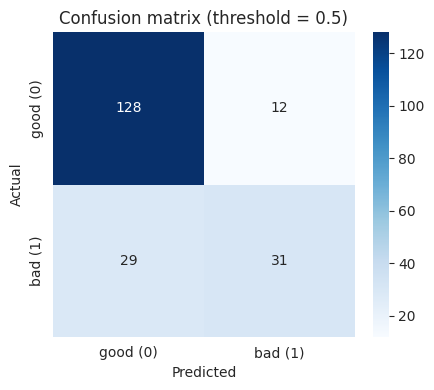

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["good (0)", "bad (1)"], yticklabels=["good (0)", "bad (1)"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

**Interpretation:** rows are the true label, columns the predicted label, at the default 0.5
probability threshold. In a credit-risk setting, the bottom-left cell (actual bad, predicted good)
is the costly error — a bad borrower approved as good — while the top-right cell (actual good,
predicted bad) is a missed-opportunity error. Given the ~70/30 class imbalance from Section 4, we'd
expect the "good" row to have more total cases; watch whether errors concentrate on the minority
"bad" row, which is the harder class to get right.

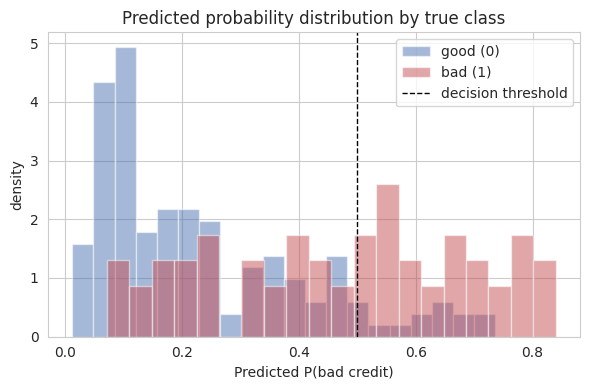

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
for cls, color, label in zip([0, 1], ["#4C72B0", "#C44E52"], ["good (0)", "bad (1)"]):
    ax.hist(proba_positive[y_test == cls], bins=20, alpha=0.5, color=color, label=label, density=True)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="decision threshold")
ax.set_xlabel("Predicted P(bad credit)")
ax.set_ylabel("density")
ax.set_title("Predicted probability distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** ideally the blue ("good") histogram sits near 0 and the red ("bad")
histogram sits near 1 — two well-separated humps. If both humps crowd around 0.5, the model is
hedging rather than confidently discriminating, which directly explains a mediocre AUC even before
looking at the ROC curve's shape.

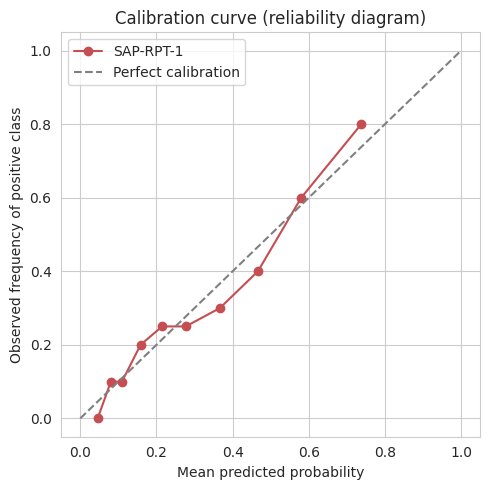

In [17]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, proba_positive, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_pred, prob_true, marker="o", color="#C44E52", label="SAP-RPT-1")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency of positive class")
ax.set_title("Calibration curve (reliability diagram)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** this is the visual companion to log-loss. Each point groups test rows by
their predicted probability and plots how often they were *actually* the positive class. A curve
hugging the diagonal means "when the model says 70% likely bad, about 70% of those rows really are
bad" — well-calibrated. A curve that sags below the diagonal at high probabilities means the model
is overconfident; one that sits above the diagonal at low probabilities means it's underconfident
there.

## 10. Save the run record

One CSV row containing everything needed to later concatenate with the other 14 datasets in
Phase 2 — same schema as `SAP_RPT1_EVAL_PLAN.md`'s recommended output.

In [18]:
import pandas as pd
import os
from datetime import datetime

os.makedirs("/kaggle/working/results", exist_ok=True)

record = {
    # dataset metadata
    "dataset": "credit-g",
    "openml_id": 31,
    "n_rows": n_rows,
    "n_features": n_features,
    "n_cat_features": len(cat_cols),
    "class_balance": round(class_balance, 4),
    "col_names_type": "meaningful",
    # run info
    "seed": 42,
    "model": "SAP-RPT-1-OSS",
    "config": "max_context_size=8192, bagging=8",
    # primary + secondary metrics
    **metrics,
    # timing
    "fit_time_sec": fit_time_sec,
    "predict_time_sec": predict_time_sec,
    "total_wall_time_sec": total_wall_time_sec,
    "peak_gpu_mem_gb": peak_mem_gb,
    # diagnostics
    "classes_": str(list(clf.classes_)),
    "context_rows": len(X_train),
    "n_train": len(y_train),
    "error": None,
    "run_timestamp": datetime.now().isoformat(timespec="seconds"),
}

out_path = "/kaggle/working/results/sap_rpt_pilot_credit-g.csv"
pd.DataFrame([record]).to_csv(out_path, index=False)
print(f"Saved pilot run record to {out_path}")
pd.DataFrame([record]).T

Saved pilot run record to /kaggle/working/results/sap_rpt_pilot_credit-g.csv


,0
dataset,credit-g
openml_id,31
n_rows,1000
n_features,20
n_cat_features,13
class_balance,0.3
col_names_type,meaningful
seed,42
model,SAP-RPT-1-OSS
config,"max_context_size=8192, bagging=8"


## 11. Pilot go/no-go summary

Before moving to Phase 2 (all 15 datasets x 5 seeds), confirm:

1. **No OOM** with `max_context_size=8192, bagging=8` on this GPU — check the peak GPU memory
   printed in Section 7 against this GPU's total memory printed in Section 1.
2. **AUC in a sane range** — the printed check in Section 8 should be well above 0.5, and ideally
   close to the expected 0.52-0.62 band for `credit-g`. A wildly different number (e.g. <0.4 or
   >0.9) usually signals an integration bug such as inverted classes, not a modeling insight.
3. **Timing extrapolation** — `total_wall_time_sec` above, multiplied by 75 total runs
   (15 datasets x 5 seeds) and scaled roughly by each dataset's row/feature count, gives a rough
   estimate of whether Phase 2 fits in one Kaggle GPU session (~9-12 hour cap) or needs to be
   split across two sessions.

If all three check out, Phase 2 wraps Sections 2-10 above into a single `run_one(openml_id, name,
seed)` function and loops it over the full 15-dataset list with checkpoint-after-every-run, exactly
as described in `SAP_RPT1_Kaggle_Evaluation_Plan.md`.